In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:/Users/Haseeb/Downloads/internship/task 4/credit_risk_dataset.csv')

In [3]:
#EDA Starts

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [9]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [11]:
df['person_emp_length'].fillna(
    df['person_emp_length'].median(),
    inplace=True)

C:\Users\Haseeb\AppData\Local\Temp\ipykernel_11560\121681827.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(


In [12]:
df['loan_int_rate'].fillna(
    df['loan_int_rate'].median(),
    inplace=True
)

C:\Users\Haseeb\AppData\Local\Temp\ipykernel_11560\3316137206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(


In [13]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

165


In [14]:
df['person_age'].describe() #checked un realistic ages

count    32416.000000
mean        27.747008
std          6.354100
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

In [16]:
df = df[(df['person_age'] >= 18) &
        (df['person_age'] <= 100)] #possible filtering on age

In [17]:
df['person_emp_length'].describe() #employement length

count    32411.000000
mean         4.768720
std          4.090478
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [19]:
df = df[df['person_emp_length'] >= 0] #remove impossible employement length

In [22]:
#outliers detection 
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

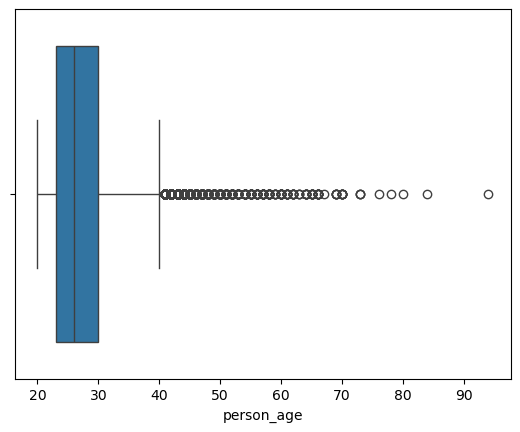

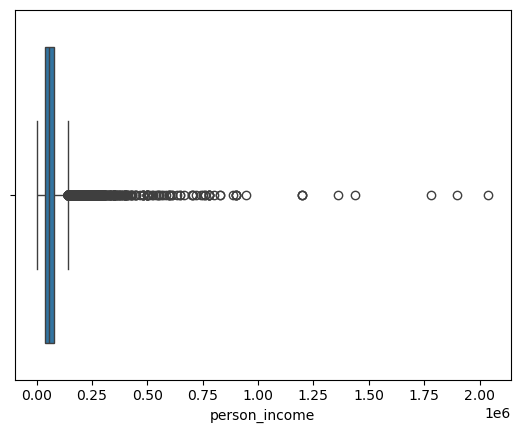

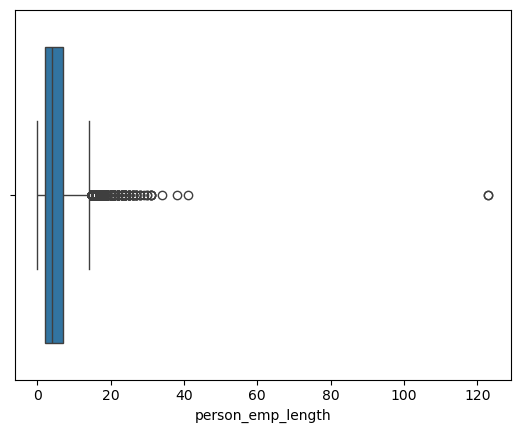

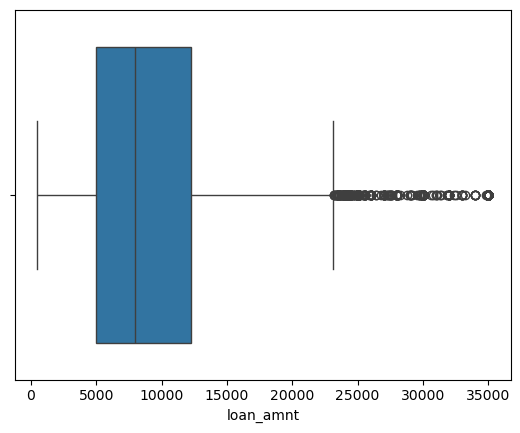

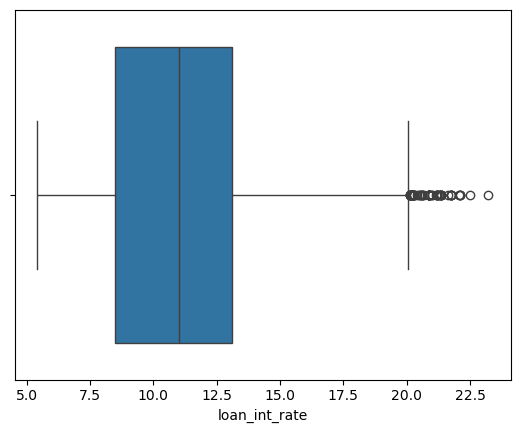

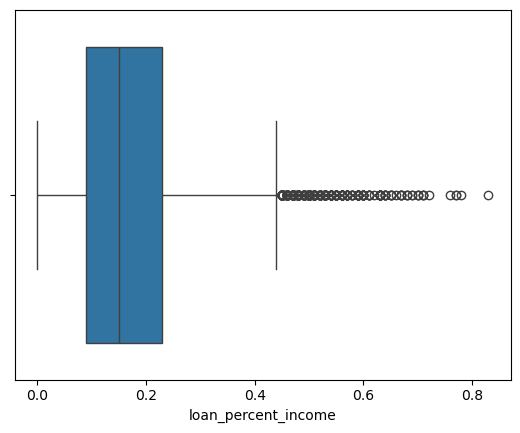

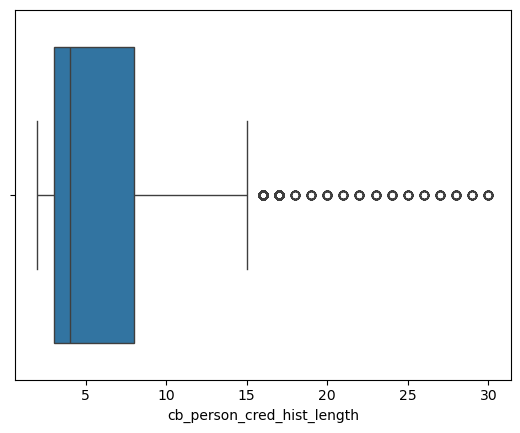

In [23]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [24]:
df['person_income'] = np.log1p(df['person_income'])

In [26]:
#categorical columns
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

In [27]:
#one hot encoding
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [29]:
X = df.drop('loan_status', axis=1)# defination of features and targets
y = df['loan_status']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
y_pred_lr = lr.predict(X_test_scaled)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8707388554681474
Precision: 0.7756653992395437
Recall: 0.5754583921015515
F1 Score: 0.6607287449392713
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5065
           1       0.78      0.58      0.66      1418

    accuracy                           0.87      6483
   macro avg       0.83      0.76      0.79      6483
weighted avg       0.86      0.87      0.86      6483



In [37]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Haseeb\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

cost_fp = 1000
cost_fn = 7000

total_cost = (fp * cost_fp) + (fn * cost_fn)

print("False Positives:", fp)
print("False Negatives:", fn)
print("Total Business Cost: $", total_cost)

False Positives: 252
False Negatives: 908
Total Business Cost: $ 6608000


In [40]:
y_proba = model.predict_proba(X_test)[:, 1]

In [41]:
cost_fp = 1000
cost_fn = 7000

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0
lowest_cost = float("inf")

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = fp * cost_fp + fn * cost_fn

    if total_cost < lowest_cost:
        lowest_cost = total_cost
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Lowest Cost:", lowest_cost)

Best Threshold: 0.15999999999999998
Lowest Cost: 3970000


In [43]:
y_pred_final = (y_proba >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print("Final Confusion Matrix:")
print(tn, fp, fn, tp)
print("Final Cost:", fp * cost_fp + fn * cost_fn)

Final Confusion Matrix:
2887 2178 256 1162
Final Cost: 3970000
